In [4]:
#loading the annotated data

import scanpy as sc
import pandas as pd
import numpy as np
 
adata = sc.read_h5ad("baseline_annotated.h5ad")

In [5]:
#checking that everything from part 2 came through
#ans: yes, and the numbers represent then number of cells from that patient that fall in that category (responder vs. non-responder)

adata.obs["cell_type"].value_counts()
pd.crosstab(adata.obs["patient"], adata.obs["response"])

response,Non-responder,Responder
patient,,
P1,0,229
P12,330,0
P15,304,0
P2,337,0
P20,323,0
P24,0,338
P25,371,0
P26,0,333
P27,343,0


In [6]:
# Per-patient cell-type fractions: each patient's cells as proportions of their total,
# with their response group attached — ready to compare responders vs non-responders. 


comp = (
    adata.obs
    .groupby("patient")["cell_type"]
    .value_counts(normalize=True)
    .rename("frac")
    .reset_index()
)
resp = adata.obs.drop_duplicates("patient").set_index("patient")["response"]
comp["response"] = comp["patient"].map(resp)
comp

C:\Users\zoehe\AppData\Local\Temp\ipykernel_44948\3857733527.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("patient")["cell_type"]


,patient,cell_type,frac,response
0,P1,Exhausted CD8 T cells,0.296943,Responder
1,P1,Naive/stem-like T cells,0.235808,Responder
2,P1,Memory CD8 T cells,0.200873,Responder
3,P1,Cytotoxic CD8 T cells,0.192140,Responder
4,P1,Monocytes/Macrophages,0.030568,Responder
...,...,...,...,...
166,P8,B cells,0.093633,Responder
167,P8,Exhausted CD8 T cells,0.041199,Responder
168,P8,Plasmacytoid dendritic cells,0.011236,Responder
169,P8,Regulatory T cells,0.011236,Responder


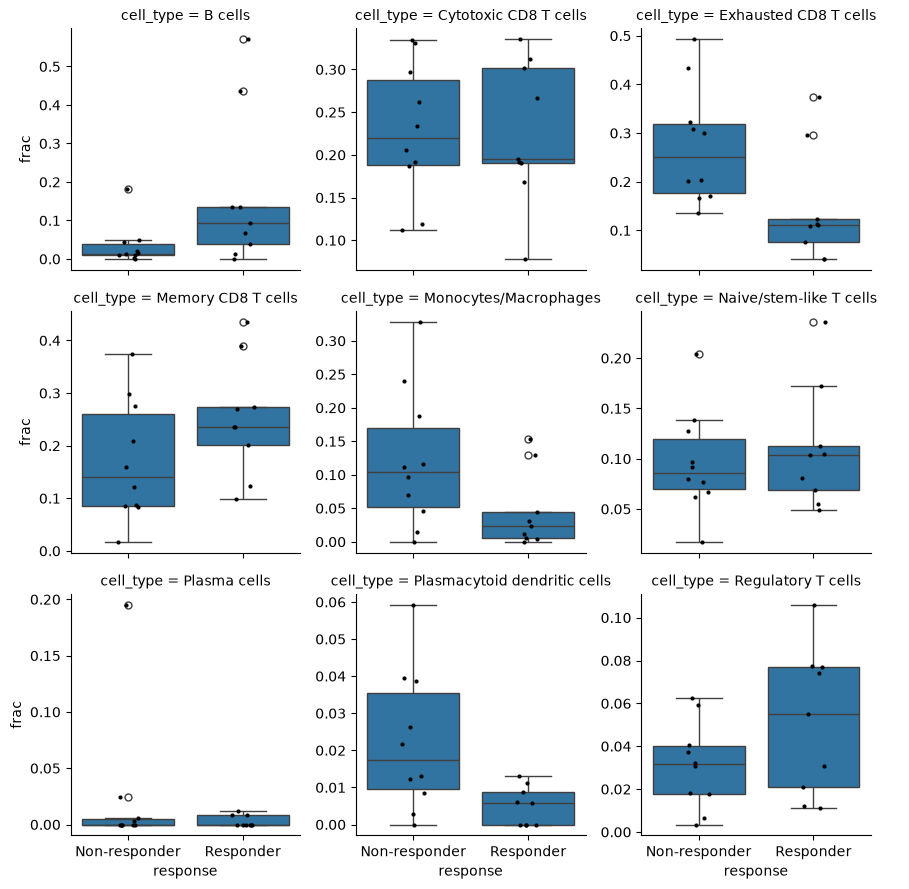

In [7]:
# Box + strip plot of each cell type's fraction, responders vs non-responders —
# box shows the group spread, dots show individual patients (watch for one or two driving a gap). 

import seaborn as sns
g = sns.catplot(
    data=comp, x="response", y="frac", col="cell_type",
    kind="box", col_wrap=3, height=3, sharey=False
)
g.map_dataframe(sns.stripplot, x="response", y="frac", color="black", size=3)

In [8]:
#i want to run scCODA and for that i need to instal pertpy, so i did so in anaconda prompt and here im just checking its worked.

import pertpy as pt
print(pt.__version__)

1.0.3


In [9]:
# Build scCODA's data object: count cells per patient per cell type,
# and attach each patient's response group as the thing to compare.
model = pt.tl.Sccoda()
sccoda_data = model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="cell_type",   # my 9 annotated types
    sample_identifier="patient",        # one sample = one patient (n≈19)
    covariate_obs=["response"],         # responders vs non-responders
)

In [11]:
# Set up the model: compare cell-type abundance by response,
# using an auto-picked "steady" cell type as the reference anchor.
sccoda_data = model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="response",
    reference_cell_type="automatic",
)

In [12]:
# Fit the model (Bayesian sampling).
model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)

sample: 100%|██████████| 11000/11000 [06:58<00:00, 26.31it/s, 127 steps of size 2.56e-02. acc. prob=0.88]
c:\Users\zoehe\miniconda3\envs\zoe-sc\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [13]:
# Read the verdict: for each cell type, True = a credible change in responders.
model.set_fdr(sccoda_data, 0.2)
model.credible_effects(sccoda_data, modality_key="coda")

Covariate              Cell Type                   
response[T.Responder]  B cells                          True
                       Cytotoxic CD8 T cells           False
                       Exhausted CD8 T cells            True
                       Memory CD8 T cells              False
                       Monocytes/Macrophages            True
                       Naive/stem-like T cells         False
                       Plasma cells                    False
                       Plasmacytoid dendritic cells    False
                       Regulatory T cells              False
Name: Final Parameter, dtype: bool

In [14]:
#Check the reference cell type scCODA auto-picked — everything is measured relative to it, so I should be able to name it

sccoda_data["coda"].uns["scCODA_params"]["reference_cell_type"]


'Regulatory T cells'

In [15]:
# Re-run with an explicit, deliberately-chosen reference to check the result is stable
sccoda_data = model.prepare(
    sccoda_data,
    modality_key="coda",
    formula="response",
    reference_cell_type="Plasma cells",   # a steady, unrelated anchor
)
model.run_nuts(sccoda_data, modality_key="coda", rng_key=1234)
model.set_fdr(sccoda_data, 0.2)
model.credible_effects(sccoda_data, modality_key="coda")

sample: 100%|██████████| 11000/11000 [06:09<00:00, 29.76it/s, 127 steps of size 2.27e-02. acc. prob=0.89]


Covariate              Cell Type                   
response[T.Responder]  B cells                          True
                       Cytotoxic CD8 T cells           False
                       Exhausted CD8 T cells            True
                       Memory CD8 T cells              False
                       Monocytes/Macrophages            True
                       Naive/stem-like T cells         False
                       Plasma cells                    False
                       Plasmacytoid dendritic cells    False
                       Regulatory T cells              False
Name: Final Parameter, dtype: bool